(102, 3)


,GeoFips,GeoName,2013
0,1998,Alabama (Metropolitan Portion),88.9
1,1999,Alabama (Nonmetropolitan Portion),82.9
2,2998,Alaska (Metropolitan Portion),110.0
3,2999,Alaska (Nonmetropolitan Portion),98.6
4,4998,Arizona (Metropolitan Portion),97.6


cluster
0          50
2          48
1           4
Name: count, dtype: int64


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5344/1601636032.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


,geofips,geoname,2013,text,cluster
0,1998,Alabama (Metropolitan Portion),88.9,alabama metropolitan portion,2
1,1999,Alabama (Nonmetropolitan Portion),82.9,alabama nonmetropolitan portion,2
2,2998,Alaska (Metropolitan Portion),110.0,alaska metropolitan portion,2
3,2999,Alaska (Nonmetropolitan Portion),98.6,alaska nonmetropolitan portion,2
4,4998,Arizona (Metropolitan Portion),97.6,arizona metropolitan portion,2


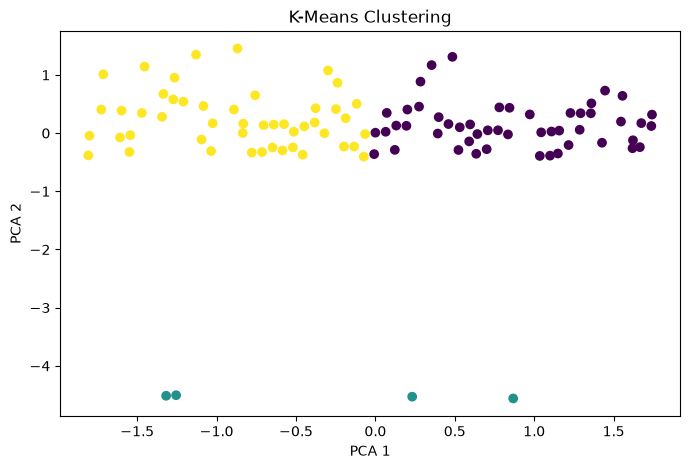

,geofips,2013
cluster,,
0,43238.480000,94.044000
1,25749.000000,0.000000
2,16477.645833,95.272917


Done!


In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Load dataset
df = pd.read_csv("bea-data-metro-vs-non-metro-rpp-2013.csv")

print(df.shape)
display(df.head())

# 3. Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 4. NLP - combine text columns
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

def clean_text(x):
    x = x.lower()
    x = re.sub(r"[^a-z\s]", " ", x)
    return x

df["text"] = df["text"].apply(clean_text)

# 5. Convert text to TF-IDF
tfidf = TfidfVectorizer(max_features=100)
X_text = tfidf.fit_transform(df["text"])

# 6. Numerical data
num_cols = df.select_dtypes(include=np.number).columns
X_num = df[num_cols].fillna(df[num_cols].median())

scaler = StandardScaler()
X_num = scaler.fit_transform(X_num)

# 7. Combine NLP + numerical data
from scipy.sparse import hstack
X = hstack([X_num, X_text])

# 8. K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

# 9. Show clusters
print(df[["cluster"]].value_counts())
display(df.head())

# 10. PCA visualization
X_pca = PCA(n_components=2).fit_transform(X.toarray())

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering")
plt.show()

# 11. Cluster summary
display(df.groupby("cluster")[num_cols].mean())

# 12. Save results
df.to_csv("kmeans_rpp_results.csv", index=False)

print("Done!")